# Employee Financial Health Model Explainability

## Objective

The purpose of this notebook is to prepare structured outputs from the trained XGBoost model for the AI Financial Advisor.

The notebook performs the following tasks:

- Loads the trained prediction pipeline.
- Generates financial health predictions.
- Calculates prediction confidence.
- Identifies globally important financial features.
- Creates a structured employee financial profile.
- Exports the profile as JSON for use by the LangChain application.

This notebook acts as the bridge between the Machine Learning pipeline and the Generative AI system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

In [2]:
pipeline = joblib.load("../models/final_xgboost_pipeline.pkl")

target_encoder = joblib.load("../models/target_encoder.pkl")

final_features = joblib.load("../models/final_features.pkl")

In [3]:
df = pd.read_csv("..\data\processed\employee_financial_procssed.csv")

In [4]:
X = df[final_features]

y = df["Class"]

In [5]:
predictions = pipeline.predict(X)

probabilities = pipeline.predict_proba(X)

In [6]:
prediction_df = pd.DataFrame({

    "Actual": y,

    "Predicted": target_encoder.inverse_transform(predictions),

    "Confidence": probabilities.max(axis=1)

})

prediction_df.head()

,Actual,Predicted,Confidence
0,High,High,0.993060
1,Low,Low,0.999599
2,Low,Low,0.997740
3,Medium,Medium,0.996825
4,Medium,Medium,0.992560


In [7]:
model = pipeline.named_steps["model"]

preprocessor = pipeline.named_steps["preprocessor"]

In [8]:
feature_names = preprocessor.get_feature_names_out()

In [9]:
importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": model.feature_importances_

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.head(15)

,Feature,Importance
14,num__Savings_Amount,0.147259
17,num__Debt_Burden_Index,0.117432
10,num__EMI_or_Loan_Payment,0.109902
8,num__Rent_Expense,0.076452
13,num__Total_Expenditure,0.057484
15,num__Investments,0.051295
16,num__Disposable_Income,0.040563
18,num__Investment_to_Savings_Ratio,0.037289
11,num__Entertainment_Expense,0.032818
12,num__Other_Expenses,0.027826


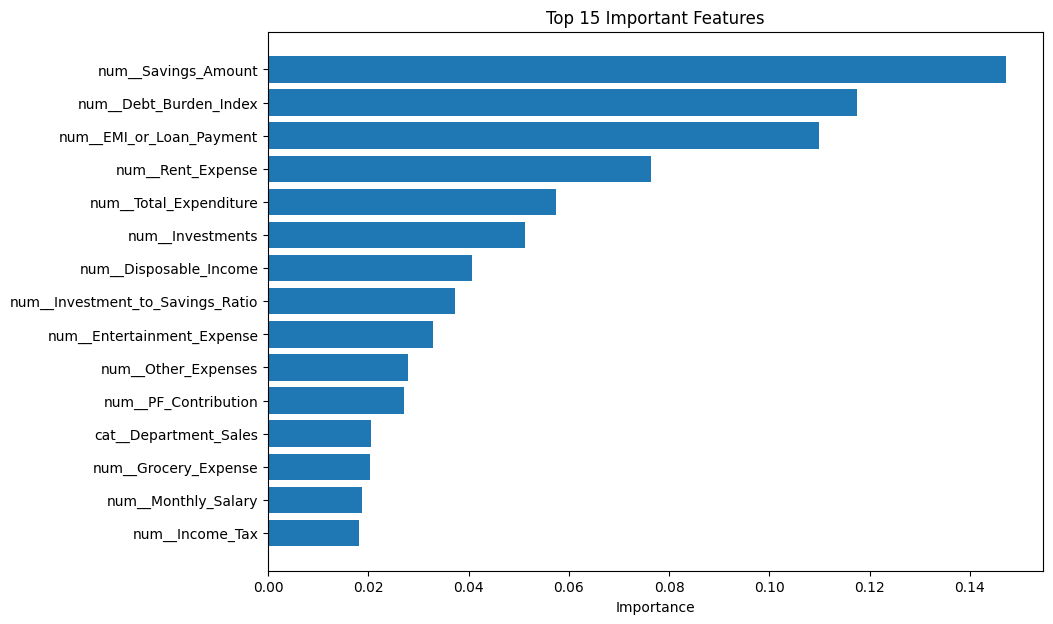

In [10]:
plt.figure(figsize=(10,7))

plt.barh(

    importance_df.head(15)["Feature"][::-1],

    importance_df.head(15)["Importance"][::-1]

)

plt.xlabel("Importance")

plt.title("Top 15 Important Features")

plt.show()

#  Build Employee Financial Profile

The purpose of this section is to transform the prediction generated by the XGBoost model into a structured financial profile.

This profile acts as the communication layer between the Machine Learning model and the AI-powered Financial Advisor.

The generated profile contains:

- Model Prediction
- Prediction Confidence
- Employee Financial Information
- Engineered Financial Metrics

The profile is later passed to the LangChain application to generate personalized financial reports.

In [11]:
employee_index = 15

employee = df.iloc[employee_index]

employee

EmployeeID                               EMP00016
EmployeeName                       Avantika Dubey
Age                                            37
Years_of_Experience                            10
Department                     Product Management
Monthly_Salary                             147355
Income_Tax                                  12804
PF_Contribution                              8841
Insurance_Deduction                          3802
Other_Deductions                             1794
Net_Salary                                 120114
Rent_Expense                                35040
Grocery_Expense                             19216
EMI_or_Loan_Payment                             0
Entertainment_Expense                        8235
Other_Expenses                               6344
Total_Expenditure                           68835
Savings_Amount                              24065
Investments                                  4701
Class                                      Medium


In [12]:
def create_employee_profile(df, prediction_df, employee_index):

    employee = df.iloc[employee_index]
    prediction = prediction_df.iloc[employee_index]

    profile = {

        "employee_information": {

            "employee_id": employee["EmployeeID"],
            "employee_name": employee["EmployeeName"],
            "department": employee["Department"],
            "age": int(employee["Age"]),
            "experience": int(employee["Years_of_Experience"])

        },

        "prediction": {

            "financial_health": prediction["Predicted"],
            "confidence": round(float(prediction["Confidence"]) * 100, 2)

        },

        "income": {

            "monthly_salary": float(employee["Monthly_Salary"]),
            "net_salary": float(employee["Net_Salary"]),
            "income_tax": float(employee["Income_Tax"]),
            "pf_contribution": float(employee["PF_Contribution"]),
            "insurance_deduction": float(employee["Insurance_Deduction"]),
            "other_deductions": float(employee["Other_Deductions"])

        },

        "expenses": {

            "rent": float(employee["Rent_Expense"]),
            "grocery": float(employee["Grocery_Expense"]),
            "emi": float(employee["EMI_or_Loan_Payment"]),
            "entertainment": float(employee["Entertainment_Expense"]),
            "other_expenses": float(employee["Other_Expenses"]),
            "total_expenditure": float(employee["Total_Expenditure"])

        },

        "assets": {

            "savings": float(employee["Savings_Amount"]),
            "investments": float(employee["Investments"])

        },

        "financial_metrics": {

            "expense_ratio": float(employee["Expense_Ratio"]),
            "savings_ratio": float(employee["Savings_Ratio"]),
            "investment_ratio": float(employee["Investment_Ratio"]),
            "emi_ratio": float(employee["EMI_Ratio"]),
            "disposable_income": float(employee["Disposable_Income"]),
            "financial_cushion": float(employee["Financial_Cushion"]),
            "debt_burden_index": float(employee["Debt_Burden_Index"]),
            "investment_to_savings_ratio": float(employee["Investment_to_Savings_Ratio"]),
            "financial_health_score": float(employee["Financial_Health"])

        }

    }

    return profile

In [13]:
employee_profile = create_employee_profile(

    df,

    prediction_df,

    employee_index

)

employee_profile

{'employee_information': {'employee_id': 'EMP00016',
  'employee_name': 'Avantika Dubey',
  'department': 'Product Management',
  'age': 37,
  'experience': 10},
 'prediction': {'financial_health': 'Medium', 'confidence': 99.14},
 'income': {'monthly_salary': 147355.0,
  'net_salary': 120114.0,
  'income_tax': 12804.0,
  'pf_contribution': 8841.0,
  'insurance_deduction': 3802.0,
  'other_deductions': 1794.0},
 'expenses': {'rent': 35040.0,
  'grocery': 19216.0,
  'emi': 0.0,
  'entertainment': 8235.0,
  'other_expenses': 6344.0,
  'total_expenditure': 68835.0},
 'assets': {'savings': 24065.0, 'investments': 4701.0},
 'financial_metrics': {'expense_ratio': 0.5730805734552176,
  'savings_ratio': 0.2003513329004112,
  'investment_ratio': 0.0391378190718817,
  'emi_ratio': 0.0,
  'disposable_income': 51279.0,
  'financial_cushion': 0.35,
  'debt_burden_index': 0.0,
  'investment_to_savings_ratio': 0.195,
  'financial_health_score': 1.0}}

#  Generate AI Input

The employee financial profile is converted into a structured JSON object.

This JSON serves as the communication layer between the Machine Learning pipeline and the LangChain-based AI Financial Advisor.

The exported JSON contains:

- Employee Information
- Prediction
- Confidence Score
- Income Details
- Expense Details
- Financial Assets
- Engineered Financial Metrics

This structured format allows the AI system to generate personalized financial reports without requiring direct access to the machine learning model.

In [14]:
import json

def export_employee_profile(profile, file_path):

    with open(file_path, "w") as file:

        json.dump(
            profile,
            file,
            indent=4
        )

    print(f"Employee profile exported to {file_path}")

In [15]:
export_employee_profile(
    employee_profile,
    "../Data/Processed/sample_employee_profile.json"
)

Employee profile exported to ../Data/Processed/sample_employee_profile.json


In [16]:
with open("../Data/Processed/sample_employee_profile.json") as file:

    sample_profile = json.load(file)

sample_profile

{'employee_information': {'employee_id': 'EMP00016',
  'employee_name': 'Avantika Dubey',
  'department': 'Product Management',
  'age': 37,
  'experience': 10},
 'prediction': {'financial_health': 'Medium', 'confidence': 99.14},
 'income': {'monthly_salary': 147355.0,
  'net_salary': 120114.0,
  'income_tax': 12804.0,
  'pf_contribution': 8841.0,
  'insurance_deduction': 3802.0,
  'other_deductions': 1794.0},
 'expenses': {'rent': 35040.0,
  'grocery': 19216.0,
  'emi': 0.0,
  'entertainment': 8235.0,
  'other_expenses': 6344.0,
  'total_expenditure': 68835.0},
 'assets': {'savings': 24065.0, 'investments': 4701.0},
 'financial_metrics': {'expense_ratio': 0.5730805734552176,
  'savings_ratio': 0.2003513329004112,
  'investment_ratio': 0.0391378190718817,
  'emi_ratio': 0.0,
  'disposable_income': 51279.0,
  'financial_cushion': 0.35,
  'debt_burden_index': 0.0,
  'investment_to_savings_ratio': 0.195,
  'financial_health_score': 1.0}}

# Conclusion

The explainability pipeline successfully transforms machine learning predictions into a structured financial profile suitable for AI-driven analysis.

The notebook performs the following tasks:

- Loads the trained XGBoost pipeline.
- Generates financial health predictions.
- Calculates prediction confidence.
- Identifies globally important financial features.
- Creates a structured employee financial profile.
- Exports the profile as a JSON object.

The generated JSON acts as the interface between the Machine Learning model and the LangChain-based AI Financial Advisor, enabling intelligent report generation and interactive financial assistance.